# Pix2pix

In [1]:
import os
import zipfile
import gdown
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Datos de entrenamiento

In [ ]:
data_link = 'https://drive.google.com/file/d/1vWAntLe0m3lkRXjXss_j3oHWULCC0btk/view?usp=share_link'

gdown.download(data_link, 'maps.zip', quiet=False, fuzzy=True)

with zipfile.ZipFile('maps.zip', 'r') as zip_data:
    zip_data.extractall('/content/data')

Downloading...
From (original): https://drive.google.com/uc?id=1vWAntLe0m3lkRXjXss_j3oHWULCC0btk
From (redirected): https://drive.google.com/uc?id=1vWAntLe0m3lkRXjXss_j3oHWULCC0btk&confirm=t&uuid=0188f64f-4a98-4e1c-86e7-dc372faa319e
To: /content/maps.zip
100%|██████████| 252M/252M [00:01<00:00, 128MB/s]


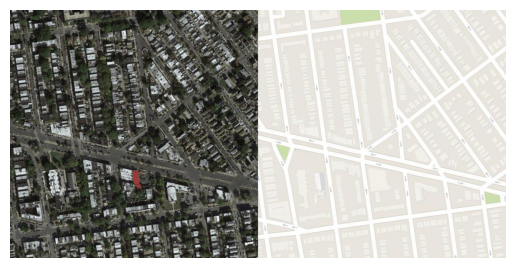

In [3]:
# Ejemplo:
img = Image.open('/content/data/maps/train/1.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

### Transformaciones para data augmentation

In [4]:
class PairedTransforms:

    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x0, x1):

        seed = torch.randint(0, 2**32, [1]).item()

        torch.manual_seed(seed)
        x0 = self.transform(x0)

        torch.manual_seed(seed)
        x1 = self.transform(x1)

        return x0, x1

### Clase `MapsDataset`

In [5]:
class MapsDataset(Dataset):

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.data_filenames = [file for file in os.listdir(root_dir) if file.endswith('jpg')]
        self.transform = PairedTransforms(transform)

    def __len__(self):
        return len(self.data_filenames)

    def __getitem__(self, n):
        img_path = os.path.join(self.root_dir, self.data_filenames[n])
        image = Image.open(img_path).convert('RGB')

        w, h = image.size
        x0 = image.crop((0, 0, w//2, h))
        x1 = image.crop((w//2, 0, w, h))

        if self.transform:
            x0, x1 = self.transform(x0, x1)

        return x0, x1

In [6]:
train_transform = transforms.Compose([
    transforms.Resize(286),
    transforms.RandomCrop(256),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

In [ ]:
train_dataset = MapsDataset(root_dir='/content/data/maps/train', transform=train_transform)
eval_dataset = MapsDataset(root_dir='/content/data/maps/val', transform=eval_transform)

# Test:
x0, x1 = train_dataset[0]
assert x0.shape == x1.shape == (3, 256, 256)

train_dataloader = DataLoader(train_dataset, batch_size=24, shuffle=True, drop_last=True, num_workers=2, pin_memory=True)
eval_dataloader = DataLoader(eval_dataset, batch_size=24, shuffle=False, drop_last=True, num_workers=2, pin_memory=True)

print(f'Dataset de entrenamiento: {len(train_dataset)} muestras.')
print(f'Dataset de validación: {len(eval_dataset)} muestras.')

Dataset de entrenamiento: 1096 muestras.
Dataset de validación: 1098 muestras.


### Visualización

In [8]:
def denormalize(batch):
    return (batch + 1).clamp(0, 2) / 2

def show_batch(x0, x1, x1_pred=None, n_images=4):

    x0 = denormalize(x0)
    x1 = denormalize(x1)
    x1_pred = denormalize(x1_pred) if x1_pred is not None else None

    n_cols = 3 if x1_pred is not None else 2
    plt.figure(figsize=(n_cols * 2, 2 * n_images))

    for n in range(n_images):

        # Imagen original:
        plt.subplot(n_images, n_cols, n_cols * n + 1)
        plt.imshow(x0[n].permute(1, 2, 0))
        plt.axis('off')
        plt.title(r'$x_0$')

        # Transformación esperada:
        plt.subplot(n_images, n_cols, n_cols * n + 2)
        plt.imshow(x1[n].permute(1, 2, 0))
        plt.axis('off')
        plt.title(r'$x_1$')

        # Transformación predicha:
        if x1_pred is not None:
            plt.subplot(n_images, n_cols, n_cols * n + 3)
            plt.imshow(x1_pred[n].permute(1, 2, 0))
            plt.axis('off')
            plt.title(r'$\tilde x_1$')

    plt.tight_layout()
    plt.show()

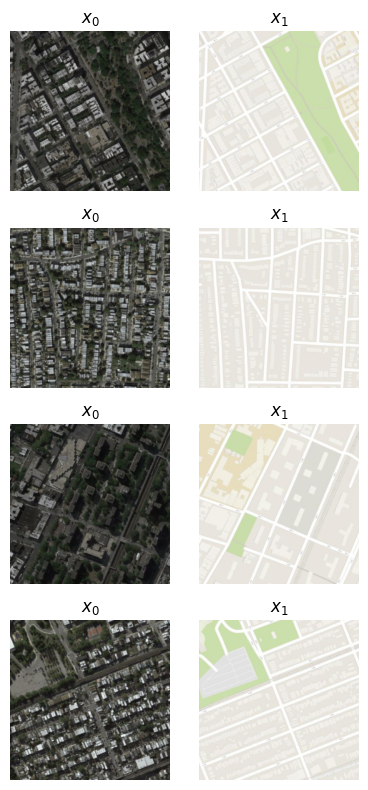

In [9]:
x0, x1 = next(iter(train_dataloader))
show_batch(x0, x1)

## Redes neuronales

### Generador

In [10]:
class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.LeakyReLU(0.2),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        return self.conv(x)

class DownBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.down = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        skip = self.conv(x)
        output = self.down(skip)
        return output, skip

class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            ConvBlock(in_channels, out_channels),
            nn.Dropout(dropout)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class UNet(nn.Module):

    def __init__(self, in_channels, n_classes, base_ch=64):
        super().__init__()

        self.down1 = DownBlock(in_channels, base_ch)
        self.down2 = DownBlock(base_ch, base_ch * 2)
        self.down3 = DownBlock(base_ch * 2, base_ch * 4)
        self.down4 = DownBlock(base_ch * 4, base_ch * 8)

        self.bottleneck = ConvBlock(base_ch * 8, base_ch * 16)

        self.up4 = UpBlock(base_ch * 16, base_ch * 8)
        self.up3 = UpBlock(base_ch * 8, base_ch * 4)
        self.up2 = UpBlock(base_ch * 4, base_ch * 2)
        self.up1 = UpBlock(base_ch * 2, base_ch,)

        self.out = nn.Sequential(
            nn.Conv2d(base_ch, n_classes, kernel_size=1),
            nn.Tanh()
        )

    def forward(self, x):
        x, skip1 = self.down1(x)
        x, skip2 = self.down2(x)
        x, skip3 = self.down3(x)
        x, skip4 = self.down4(x)

        x = self.bottleneck(x)

        x = self.up4(x, skip4)
        x = self.up3(x, skip3)
        x = self.up2(x, skip2)
        x = self.up1(x, skip1)

        return self.out(x)

### Discriminador


In [11]:
class PatchGAN(nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels * 2, 64, kernel_size=4, stride=2, padding=1, bias=True),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=True),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=True),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, bias=True),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1, bias=True)
        )

    def forward(self, x0, x1):
        x = torch.cat([x0, x1], dim=1)
        return self.model(x)

## Entrenamiento y generación

### Inicialización

In [12]:
def init_weights(module):

    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(module.weight.data, 0.0, 0.02)

    elif isinstance(module, nn.InstanceNorm2d):
        if module.weight is not None:
            nn.init.normal_(module.weight.data, 1.0, 0.02)
        if module.bias is not None:
            nn.init.constant_(module.bias.data, 0.0)

### Bucle de entrenamiento

In [ ]:
def train_pix2pix(G, D, train_dataloader, val_dataloader, n_epochs, init_fn=init_weights, patience=10):

    # Redes neuronales:
    G = G.to(DEVICE).apply(init_fn)
    D = D.to(DEVICE).apply(init_fn)

    # Optimizadores:
    optimizer_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.999))

    # Schedulers:
    scheduler_G = optim.lr_scheduler.StepLR(optimizer_G, step_size=50, gamma=0.5)
    scheduler_D = optim.lr_scheduler.StepLR(optimizer_D, step_size=50, gamma=0.5)

    dataloaders = {'train': train_dataloader, 'eval': val_dataloader}

    losses = {'train': {'G': [], 'D': []}, 'eval': {'G': [], 'D': []}}
    training_log = {'G': None, 'D': None, 'losses': losses}

    gan_loss = nn.BCEWithLogitsLoss()
    l1_loss  = nn.L1Loss()
    lambda_loss = 100
    best_val_loss, patience_counter = float('inf'), 0
    val_iter = iter(val_dataloader)

    # Entrenamiento y validación:
    try:
        for epoch in range(n_epochs):

            for mode in ('train', 'eval'):

                G.train(mode == 'train')
                D.train(mode == 'train')

                sum_loss_G, sum_loss_D = 0.0, 0.0

                for x0, x1 in tqdm(dataloaders[mode], desc=f'Época {epoch+1}/{n_epochs} [{mode}]', leave=False):
                    x0, x1 = x0.to(DEVICE), x1.to(DEVICE)

                    with torch.set_grad_enabled(mode == 'train'):

                        # Discriminador ----------------------------------------

                        with torch.no_grad():
                            fake_detached = G(x0)

                            if mode == 'train':
                                std = 0.05 * (1 - epoch / n_epochs)
                                x0_r = (x0.detach() + torch.randn_like(x0) * std).clamp(-1, 1)
                                x1_r = (x1.detach() + torch.randn_like(x1) * std).clamp(-1, 1)
                                fake_r = (fake_detached + torch.randn_like(fake_detached) * std).clamp(-1, 1)
                            else:
                                x0_r, x1_r, fake_r = x0, x1, fake_detached

                        if mode == 'train':
                            optimizer_D.zero_grad()

                        real_pred = D(x0_r, x1_r)
                        fake_pred = D(x0_r, fake_r)
                        real_lbl = torch.ones_like(real_pred) * 0.9
                        fake_lbl = torch.zeros_like(fake_pred)

                        loss_D = gan_loss(real_pred, real_lbl) + gan_loss(fake_pred, fake_lbl)

                        if mode == 'train':
                            loss_D.backward()
                            optimizer_D.step()

                        # Generador --------------------------------------------

                        if mode == 'train':
                            optimizer_G.zero_grad()

                        fake = G(x0)
                        pred_fake = D(x0, fake)
                        loss_G = gan_loss(pred_fake, torch.ones_like(pred_fake) * 0.9) + lambda_loss * l1_loss(fake, x1)

                        if mode == 'train':
                            loss_G.backward()
                            optimizer_G.step()

                    # ----------------------------------------------------------

                    sum_loss_G += loss_G.item()
                    sum_loss_D += loss_D.item()

                losses[mode]['G'].append(sum_loss_G / len(dataloaders[mode]))
                losses[mode]['D'].append(sum_loss_D / len(dataloaders[mode]))

                if mode == 'train':
                    scheduler_G.step()
                    scheduler_D.step()

            # Early stopping:
            val_loss = losses['eval']['G'][-1]
            if val_loss < best_val_loss:
                best_val_loss, patience_counter = val_loss, 0
                training_log['G'] = G.state_dict()
                training_log['D'] = D.state_dict()
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f'Early stopping en época {epoch+1}.')
                    break

            # Visualización de resultados:
            x0_val, x1_val = next(val_iter)
            x0_val, x1_val = x0_val[:1], x1_val[:1]
            x1_val_pred = G(x0_val.to(DEVICE)).detach().cpu()
            show_batch(x0_val, x1_val, x1_val_pred, n_images=1)

    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')

    torch.save(training_log, 'training.pt')

### Entrenamiento

In [ ]:
# Redes neuronales:
generator = UNet(in_channels=3, n_classes=3)
discriminator = PatchGAN(in_channels=3)

# Entrenamiento:
train_pix2pix(generator, discriminator, train_dataloader, eval_dataloader, n_epochs=100)

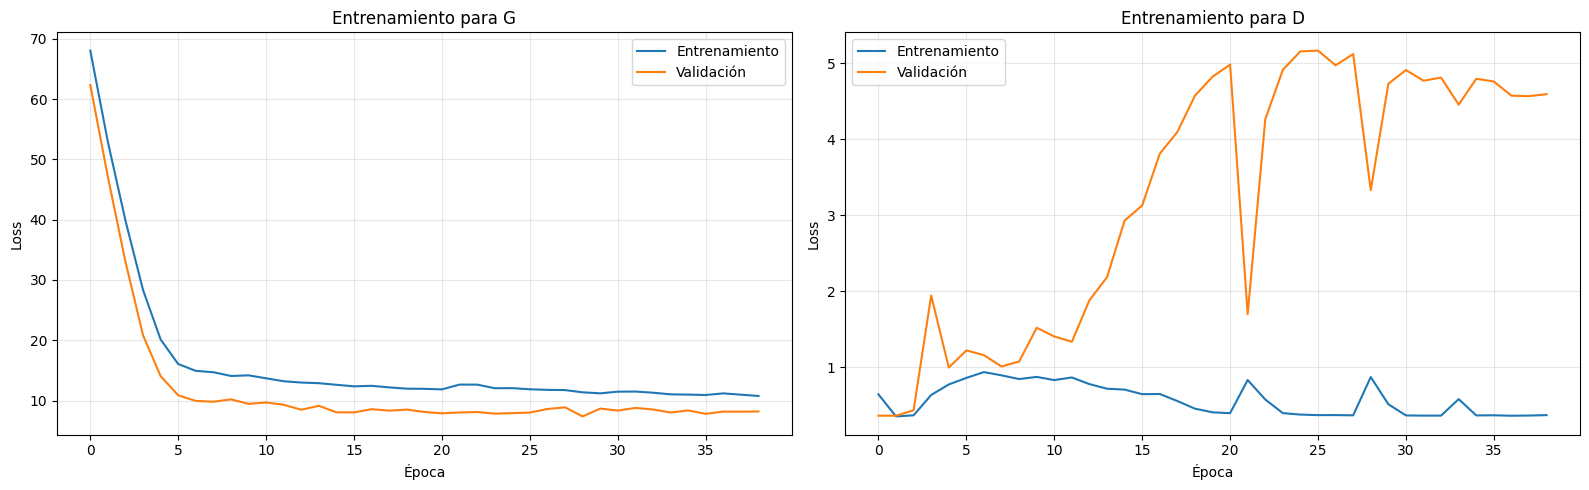

In [15]:
ckpt = torch.load('training.pt', map_location=DEVICE)
generator.load_state_dict(ckpt['G'])
discriminator.load_state_dict(ckpt['D'])

fig, axs = plt.subplots(1, 2, figsize=(16, 5))
for ax, model in zip(axs, ('G', 'D')):
    ax.plot(ckpt['losses']['train'][model], label='Entrenamiento')
    ax.plot(ckpt['losses']['eval'][model], label='Validación')
    ax.set_title(f'Entrenamiento para {model}')
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generación


In [16]:
def generate(generator, x0):

    generator.eval()
    x0 = x0.to(DEVICE)
    G = generator.to(DEVICE)

    with torch.no_grad():
        x1_pred = G(x0)

    return x1_pred

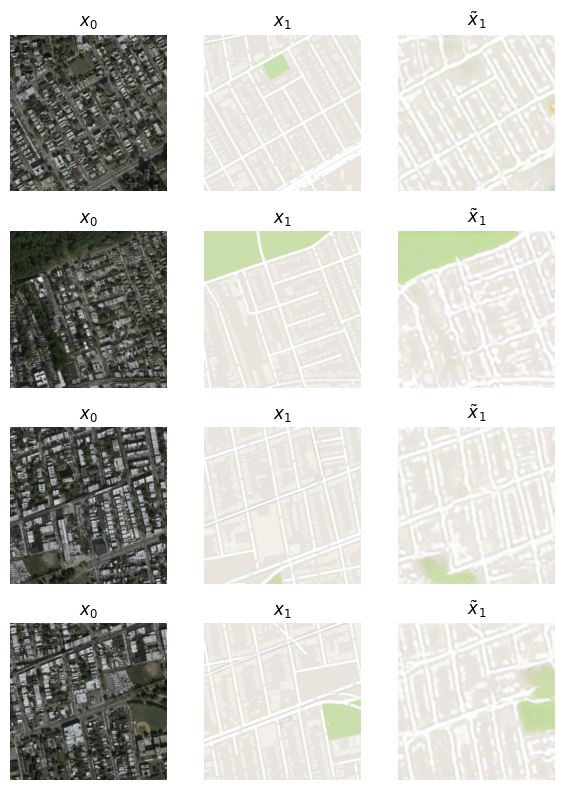

In [17]:
x0, x1 = next(iter(eval_dataloader))

x1_pred = generate(generator, x0).detach().cpu()
show_batch(x0, x1, x1_pred, n_images=len(x0))